# 1. Import libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
import warnings
warnings.filterwarnings("ignore")

# 2. Load dataset

In [59]:
#Load data
df = pd.read_csv("StudentPerformanceFactors.csv")
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


# 3. Basic info about the data

In [60]:
df.shape

(6607, 20)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [62]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [63]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [64]:
# Check missing values
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [65]:
# missing values percent
missing_percent = (df.isnull().sum()[df.isnull().sum() > 0] / len(df)) * 100
print(missing_percent.round(2).astype(str) + ' %')


Teacher_Quality             1.18 %
Parental_Education_Level    1.36 %
Distance_from_Home          1.01 %
dtype: object


# 3.1. Missing Value Handling
Fill missing values in categorical columns using the most frequent (mode) value
This prevents data loss and maintains dataset integrity


In [66]:
# Thay thế bằng giá trị xuất hiện nhiều nhất
df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0], inplace=True)
df['Parental_Education_Level'].fillna(df['Parental_Education_Level'].mode()[0], inplace=True)
df['Distance_from_Home'].fillna(df['Distance_from_Home'].mode()[0], inplace=True)

In [67]:
# Kiểm tra lại
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

# 3.2. Visualization - Numeric Features 

## 3.2.1 Numeric Features

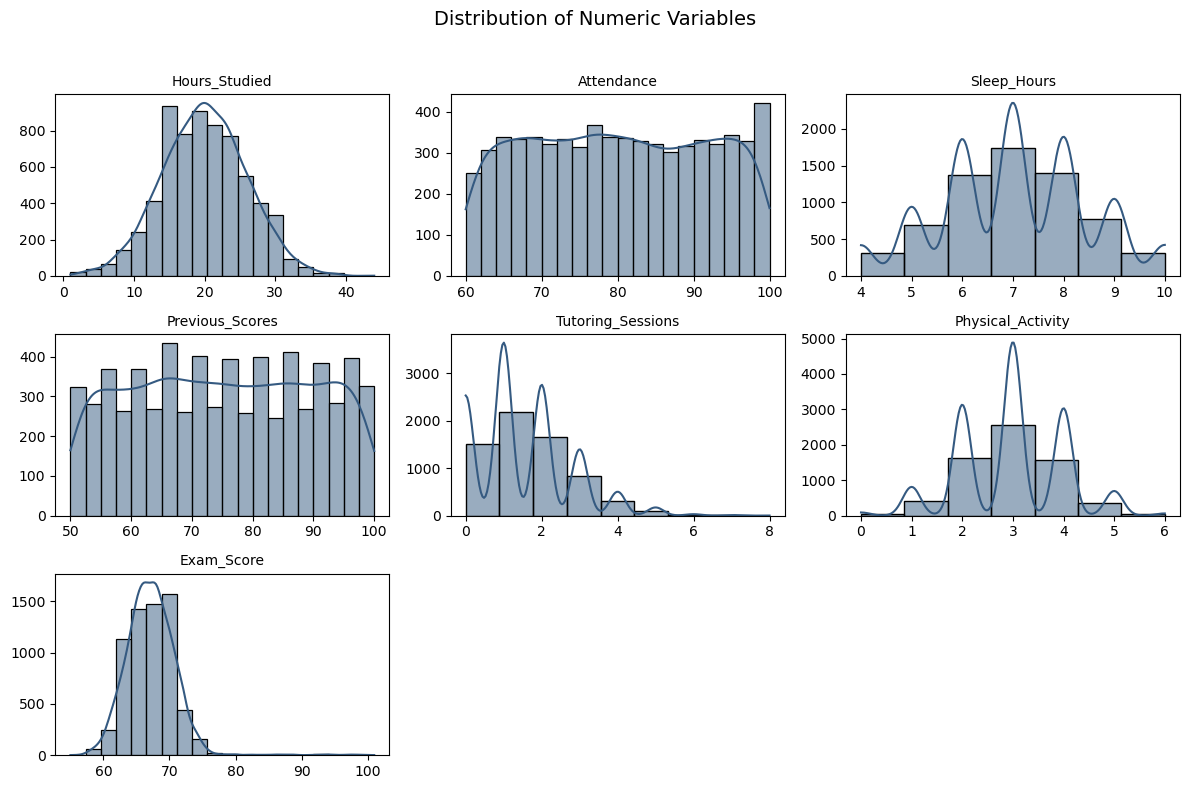

In [68]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Tạo khung lưới nhỏ gọn (số hàng, số cột có thể chỉnh)
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:len(axes)]):
    if df[col].nunique() < 15:
        bins = df[col].nunique()
    else:
        bins = 20
    sns.histplot(df[col], kde=True, bins=bins, color='#355a81', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    
# Ẩn các ô trống nếu có
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Numeric Variables', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

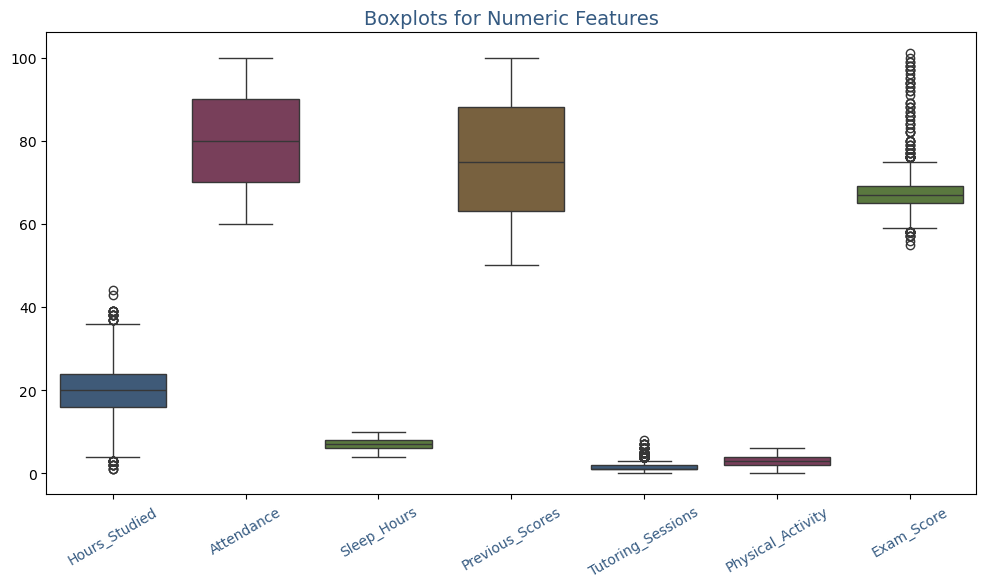

In [69]:
# Biểu đồ boxplot cho biến định lượng
tetradic_colors = ['#355a81', '#81355a', '#5a8135', '#816335']

plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numeric_cols], palette=tetradic_colors)
plt.title('Boxplots for Numeric Features', color='#355a81', fontsize=14)
plt.xticks(rotation=30, color='#355a81', fontsize=10)
plt.show()

In [70]:
# Hàm thể hiện giá trị ngoại lai của từng biến
def show_outlier_values(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)][col]
        outliers = outliers.sort_values(ascending=False)
        
        print(f"\nColumn: {col}")
        print(f"Number of outliers: {outliers.shape[0]}")
        print(lower_limit)
        print(upper_limit)
        
        print("Outlier values:")
        print(outliers.values)  # show outlier values
        print("-"*50)

# Columns to check
columns_to_check = ['Exam_Score', 'Hours_Studied', 'Tutoring_Sessions']

# Show only outlier values
show_outlier_values(df, columns_to_check)



Column: Exam_Score
Number of outliers: 104
59.0
75.0
Outlier values:
[101 100  99  99  98  98  98  97  97  97  96  95  95  94  94  94  94  93
  93  92  92  91  89  89  89  88  88  88  87  87  86  86  86  86  85  84
  84  84  83  82  82  82  82  80  80  80  80  80  79  79  79  78  78  78
  78  77  77  77  77  77  76  76  76  76  76  76  76  76  76  76  76  76
  76  76  76  76  58  58  58  58  58  58  58  58  58  58  58  58  58  58
  58  58  58  58  58  58  58  58  57  57  57  57  56  55]
--------------------------------------------------

Column: Hours_Studied
Number of outliers: 43
4.0
36.0
Outlier values:
[44 43 39 39 39 39 39 39 39 38 38 38 38 38 38 38 37 37 37 37 37 37  3  3
  3  3  3  3  3  3  3  3  3  3  2  2  2  2  2  2  1  1  1]
--------------------------------------------------

Column: Tutoring_Sessions
Number of outliers: 430
-0.5
3.5
Outlier values:
[8 7 7 7 7 7 7 7 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 6 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 

In [71]:
# Hàm để loại trừ giá trị ngoại lai bằng phương pháp IQR
def detect_outliers_with_percentage(df, col):
    total = df.shape[0]
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Before capping
    n_out_before = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    pct_before = (n_out_before / total) * 100

    # Apply capping
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

    # After capping
    n_out_after = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    pct_after = (n_out_after / total) * 100

    # Display results
    print(f"\nColumn: {col}")
    print(f"  Outliers before: {n_out_before} ({pct_before:.2f}%)")
    print(f"  Outliers after : {n_out_after} ({pct_after:.2f}%)")

    return df

In [72]:
numeric_features = [
    'Hours_Studied', 'Tutoring_Sessions', 'Exam_Score'
]

# Work on a clean copy
df_clean = df.copy()

for col in numeric_features:
    if col in df_clean.columns:
        df_clean = detect_outliers_with_percentage(df_clean, col)
    else:
        print(f"Warning: Column {col} not in DataFrame.")


Column: Hours_Studied
  Outliers before: 43 (0.65%)
  Outliers after : 0 (0.00%)

Column: Tutoring_Sessions
  Outliers before: 430 (6.51%)
  Outliers after : 0 (0.00%)

Column: Exam_Score
  Outliers before: 104 (1.57%)
  Outliers after : 0 (0.00%)


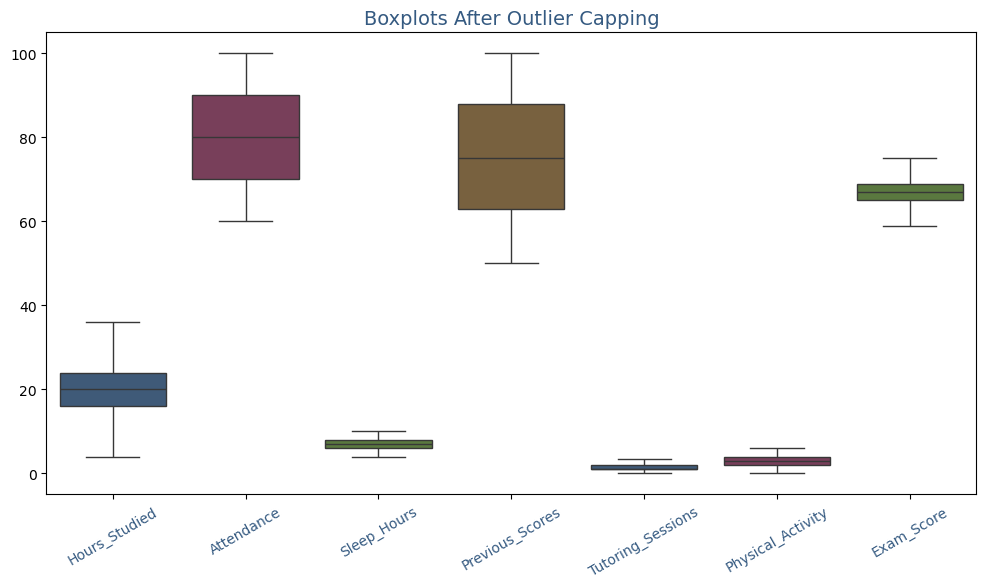

In [73]:
# Biểu đồ boxplot để xác nhận lại sau khi loại giá trị ngoại lai
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean[numeric_cols], palette=tetradic_colors)
plt.title('Boxplots After Outlier Capping', color='#355a81', fontsize=14)
plt.xticks(rotation=30, color='#355a81', fontsize=10)
plt.show()

In [74]:
correlation_matrix = df_clean[numeric_cols].corr()

correlation_matrix

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.009990,0.010697,0.024307,-0.015836,0.004760,0.504684
Attendance,-0.009990,1.000000,-0.015918,-0.020186,0.013976,-0.022435,0.660555
Sleep_Hours,0.010697,-0.015918,1.000000,-0.021750,-0.008728,-0.000378,-0.014136
Previous_Scores,0.024307,-0.020186,-0.021750,1.000000,-0.018995,-0.011274,0.195737
Tutoring_Sessions,-0.015836,0.013976,-0.008728,-0.018995,1.000000,0.008890,0.169505
Physical_Activity,0.004760,-0.022435,-0.000378,-0.011274,0.008890,1.000000,0.037263
Exam_Score,0.504684,0.660555,-0.014136,0.195737,0.169505,0.037263,1.000000


In [75]:
ones_corr = np.ones_like(correlation_matrix, dtype = bool)
ones_corr

array([[ True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True]])

In [76]:
mask = np.triu(ones_corr)
mask

array([[ True,  True,  True,  True,  True,  True,  True],
       [False,  True,  True,  True,  True,  True,  True],
       [False, False,  True,  True,  True,  True,  True],
       [False, False, False,  True,  True,  True,  True],
       [False, False, False, False,  True,  True,  True],
       [False, False, False, False, False,  True,  True],
       [False, False, False, False, False, False,  True]])

In [77]:
mask = mask[1:,:-1]
mask

array([[False,  True,  True,  True,  True,  True],
       [False, False,  True,  True,  True,  True],
       [False, False, False,  True,  True,  True],
       [False, False, False, False,  True,  True],
       [False, False, False, False, False,  True],
       [False, False, False, False, False, False]])

In [78]:
correlation_matrix = correlation_matrix.iloc[1:,:-1]

Text(0.0, 1.0, 'CORRELATION MATRIX')

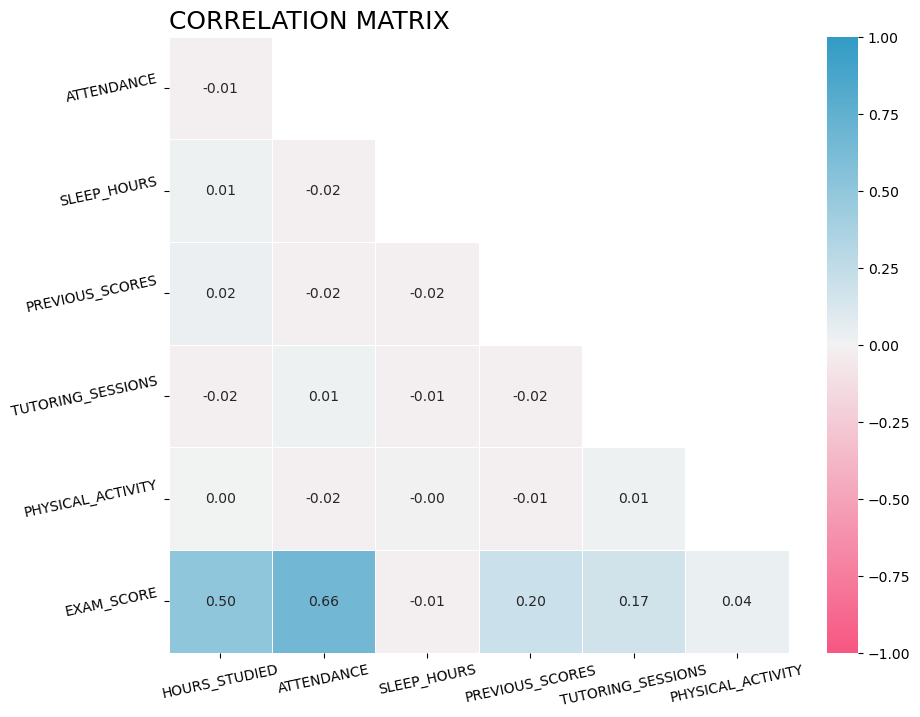

In [79]:
fig, ax = plt.subplots(figsize=(10,8))

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap = True)

sns.heatmap(data = correlation_matrix, mask = mask,
           annot = True, fmt = '.2f', cmap = cmap,
           vmin = -1, vmax = 1,
           linecolor = 'white', linewidths = 0.5)

yticks = [i.upper() for i in correlation_matrix.index]
xticks = [i.upper() for i in correlation_matrix.columns]

ax.set_yticklabels(yticks, rotation = 12, fontsize = 10)
ax.set_xticklabels(xticks, rotation = 12, fontsize = 10)
title = 'CORRELATION MATRIX'
ax.set_title(title, loc = 'left', fontsize = 18)

# 3.2.2. Visualization - Categorical Features
 Count plots for categorical variables

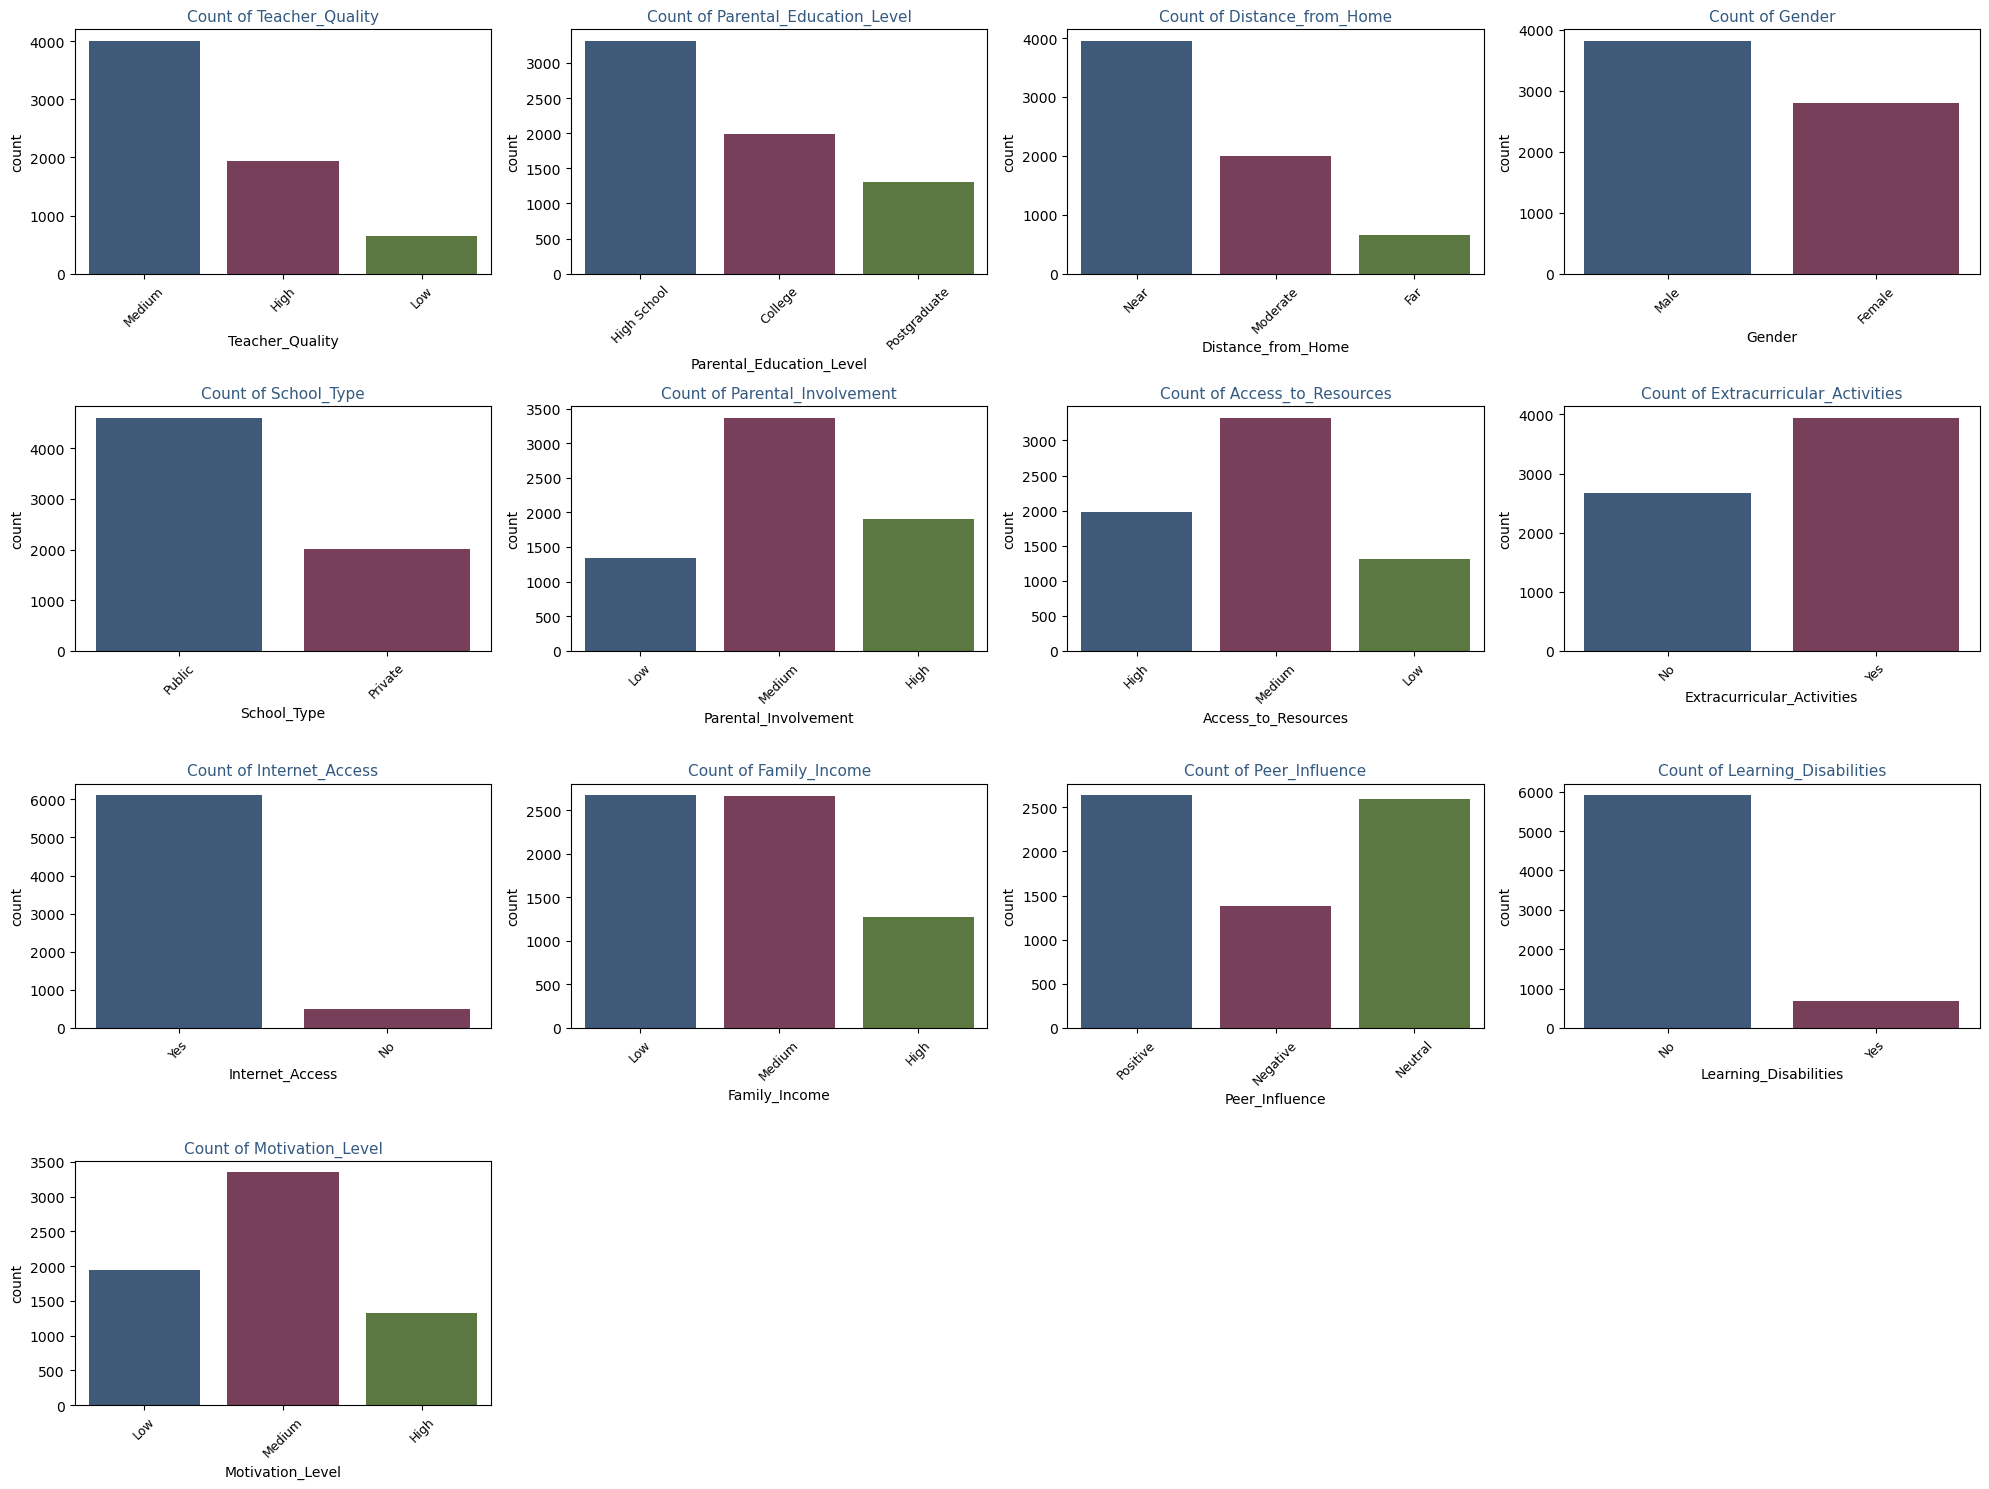

In [80]:
categorical_cols = [
    'Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home',
    'Gender', 'School_Type', 'Parental_Involvement', 'Access_to_Resources',
    'Extracurricular_Activities', 'Internet_Access', 'Family_Income',
    'Peer_Influence', 'Learning_Disabilities', 'Motivation_Level'
]


plt.figure(figsize=(20, 15))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(4, 4, i)
    sns.countplot(x=col, data=df_clean, palette=tetradic_colors)
    plt.xticks(rotation=45, fontsize=9)
    plt.title(f'Count of {col}', color='#355a81', fontsize=11)
plt.tight_layout()
plt.show()

In [81]:
# Use LabelEncoder for ordinal categories 
from sklearn.preprocessing import LabelEncoder

df_encoded = df_clean.copy()

# Define Ordinal Encoding 
ordinal_cols = ['Parental_Education_Level', 'Motivation_Level', 'Teacher_Quality']
le = LabelEncoder()
for col in ordinal_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [82]:
# Use OneHotEncoder for nominal categories
# Define nominal categories 
nominal_cols = ['Gender', 'School_Type', 'Distance_from_Home',
                'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities',
                'Internet_Access', 'Family_Income', 'Peer_Influence', 'Learning_Disabilities']

# Keep only existing columns to avoid KeyError
nominal_cols_existing = [col for col in nominal_cols if col in df_encoded.columns]

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols_existing, drop_first=True)

In [83]:
df_encoded

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Teacher_Quality,Physical_Activity,Parental_Education_Level,Exam_Score,...,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,Extracurricular_Activities_Yes,Internet_Access_Yes,Family_Income_Low,Family_Income_Medium,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes
0,23.0,84,7,73,1,0.0,2,3,1,67.0,...,False,False,False,False,True,True,False,False,True,False
1,19.0,64,8,59,1,2.0,2,4,0,61.0,...,False,False,True,False,True,False,True,False,False,False
2,24.0,98,7,91,2,2.0,2,4,2,74.0,...,True,False,True,True,True,False,True,True,False,False
3,29.0,89,8,98,2,1.0,2,4,1,71.0,...,False,False,True,True,True,False,True,False,False,False
4,19.0,92,6,65,2,3.0,0,4,0,70.0,...,True,False,True,True,True,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25.0,69,7,76,2,1.0,2,2,1,68.0,...,False,False,True,False,True,False,False,False,True,False
6603,23.0,76,8,81,2,3.0,0,2,1,69.0,...,False,False,True,False,True,True,False,False,True,False
6604,20.0,90,6,65,1,3.0,2,2,2,68.0,...,True,True,False,True,True,True,False,False,False,False
6605,10.0,86,6,91,0,2.0,2,3,1,68.0,...,False,False,False,True,True,True,False,False,True,False


In [84]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Hours_Studied                   6607 non-null   float64
 1   Attendance                      6607 non-null   int64  
 2   Sleep_Hours                     6607 non-null   int64  
 3   Previous_Scores                 6607 non-null   int64  
 4   Motivation_Level                6607 non-null   int64  
 5   Tutoring_Sessions               6607 non-null   float64
 6   Teacher_Quality                 6607 non-null   int64  
 7   Physical_Activity               6607 non-null   int64  
 8   Parental_Education_Level        6607 non-null   int64  
 9   Exam_Score                      6607 non-null   float64
 10  Gender_Male                     6607 non-null   bool   
 11  School_Type_Public              6607 non-null   bool   
 12  Distance_from_Home_Moderate     66

In [85]:
# Convert all boolean columns to 0 and 1
df_encoded = df_encoded.astype(int)
df_encoded

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Teacher_Quality,Physical_Activity,Parental_Education_Level,Exam_Score,...,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,Extracurricular_Activities_Yes,Internet_Access_Yes,Family_Income_Low,Family_Income_Medium,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes
0,23,84,7,73,1,0,2,3,1,67,...,0,0,0,0,1,1,0,0,1,0
1,19,64,8,59,1,2,2,4,0,61,...,0,0,1,0,1,0,1,0,0,0
2,24,98,7,91,2,2,2,4,2,74,...,1,0,1,1,1,0,1,1,0,0
3,29,89,8,98,2,1,2,4,1,71,...,0,0,1,1,1,0,1,0,0,0
4,19,92,6,65,2,3,0,4,0,70,...,1,0,1,1,1,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,7,76,2,1,2,2,1,68,...,0,0,1,0,1,0,0,0,1,0
6603,23,76,8,81,2,3,0,2,1,69,...,0,0,1,0,1,1,0,0,1,0
6604,20,90,6,65,1,3,2,2,2,68,...,1,1,0,1,1,1,0,0,0,0
6605,10,86,6,91,0,2,2,3,1,68,...,0,0,0,1,1,1,0,0,1,0


In [86]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   Hours_Studied                   6607 non-null   int64
 1   Attendance                      6607 non-null   int64
 2   Sleep_Hours                     6607 non-null   int64
 3   Previous_Scores                 6607 non-null   int64
 4   Motivation_Level                6607 non-null   int64
 5   Tutoring_Sessions               6607 non-null   int64
 6   Teacher_Quality                 6607 non-null   int64
 7   Physical_Activity               6607 non-null   int64
 8   Parental_Education_Level        6607 non-null   int64
 9   Exam_Score                      6607 non-null   int64
 10  Gender_Male                     6607 non-null   int64
 11  School_Type_Public              6607 non-null   int64
 12  Distance_from_Home_Moderate     6607 non-null   int64
 13  Dis

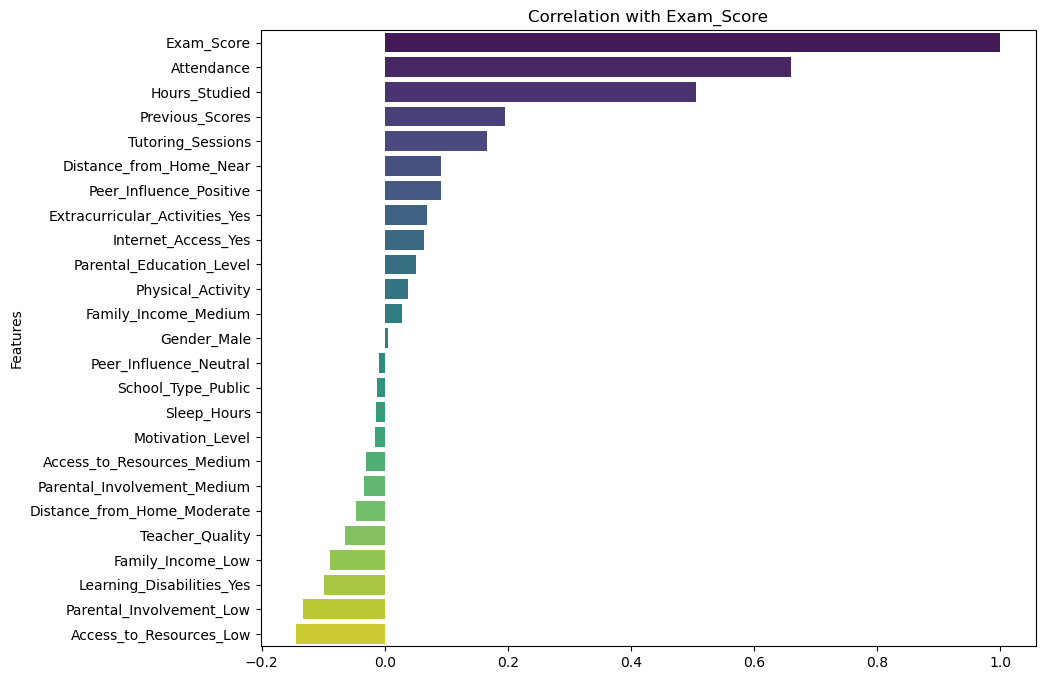

In [87]:
corr_target = df_encoded.corr()['Exam_Score'].sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=corr_target.values, y=corr_target.index, palette='viridis')
plt.title("Correlation with Exam_Score")
plt.ylabel("Features")

plt.show()

# 4. Split and scale data

In [88]:
# Target variable
y = df_encoded['Exam_Score']

# Features
X = df_encoded.drop(columns=['Exam_Score'])

#Train/Valid/Test Split 
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_valid, y_test, y_valid = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [89]:
# Scale numerical features (StandardScaler for normalization)
num_features = [
    'Hours_Studied', 'Attendance',
    'Previous_Scores', 'Tutoring_Sessions', 'Sleep_Hours', 'Physical_Activity'
]
scaler = StandardScaler()  # Initialize scaler
X_train[num_features] = scaler.fit_transform(X_train[num_features])  # Fit and transform train
X_valid[num_features] = scaler.transform(X_valid[num_features])  # Transform valid
X_test[num_features] = scaler.transform(X_test[num_features])  # Transform test

# 5. Train model

## 5.1. Linear Regression Model

In [90]:
# Huấn luyện mô hình Linear Regression (Full Features)
lr = LinearRegression()  
lr.fit(X_train, y_train)  

LinearRegression()

In [91]:
# Dự đoán
y_pred_linear = lr.predict(X_valid)  

In [93]:
# Đánh giá mô hình
mae = mean_absolute_error(y_valid, y_pred_linear)
mse = mean_squared_error(y_valid, y_pred_linear)          # Mean Squared Error
rmse = np.sqrt(mse)                                # Root Mean Squared Error
mae = mean_absolute_error(y_valid, y_pred_linear)         # Mean Absolute Error
r2 = r2_score(y_valid, y_pred_linear)                     # R-squared

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}") 
print(f"Mô hình giải thích được {r2*100:.2f}% phương sai của biến mục tiêu Exam_Score") 

MAE:  0.5531
MSE:  0.6547
RMSE: 0.8091
R²:   0.9414
Mô hình giải thích được 94.14% phương sai của biến mục tiêu Exam_Score


## 5.2. Ridge Regression Model

In [94]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_val_score
import math

# Các giá trị alpha cần thử
alphas = [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100, 1000]

# Ridge có cross-validation tự động
ridge_cv = RidgeCV(alphas=alphas, scoring='r2')
ridge_cv.fit(X_train, y_train)

# Dự đoán trên tập validation
y_pred_ridge = ridge_cv.predict(X_valid)

# Tự kiểm tra score từng alpha bằng cross_val_score
results = []
for a in alphas:
    model = Ridge(alpha=a)
    scores = cross_val_score(model, X_train, y_train, scoring='r2', cv=5)
    results.append((a, scores.mean()))
# In dạng bảng Markdown ASCII thẳng hàng
print("| Alpha      | R2 Score   |")
print("|------------|------------|")
for a, r2 in results:
    print(f"| {a:<10} | {r2:<10.6f} |")
# In alpha tối ưuc
print("────────────────────────────────────────")
print(f"Alpha tốt nhất: {ridge_cv.alpha_}")


| Alpha      | R2 Score   |
|------------|------------|
| 0.0001     | 0.900234   |
| 0.001      | 0.900234   |
| 0.01       | 0.900234   |
| 0.1        | 0.900235   |
| 1          | 0.900236   |
| 10         | 0.900150   |
| 100        | 0.893335   |
| 1000       | 0.797033   |
────────────────────────────────────────
Alpha tốt nhất: 1.0


In [95]:
# Tính các chỉ số đánh giá
mae = mean_absolute_error(y_valid, y_pred_ridge)
mse = mean_squared_error(y_valid, y_pred_ridge)
rmse = math.sqrt(mse)
r2 = r2_score(y_valid, y_pred_ridge)

# In kết quả
print("KẾT QUẢ HỒI QUY RIDGE (TÌM ALPHA TỐI ƯU)")
print("────────────────────────────────────────")
print(f"Alpha tốt nhất: {ridge_cv.alpha_}")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")
print(f"Mô hình giải thích được {r2*100:.2f}% phương sai của biến mục tiêu Exam_Score") 

KẾT QUẢ HỒI QUY RIDGE (TÌM ALPHA TỐI ƯU)
────────────────────────────────────────
Alpha tốt nhất: 1.0
MAE:  0.5531
MSE:  0.6546
RMSE: 0.8091
R²:   0.9414
Mô hình giải thích được 94.14% phương sai của biến mục tiêu Exam_Score


## 5.3. Lasso  Regression Model

In [96]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import math

# Huấn luyện mô hình Lasso với cross-validation để tìm alpha tốt nhất
lasso = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, random_state=42)
lasso.fit(X_train, np.ravel(y_train))

# Dự đoán trên tập validation
y_lasso_pred = lasso.predict(X_valid)

# Tính toán các chỉ số đánh giá
mae = mean_absolute_error(y_valid, y_lasso_pred)
mse = mean_squared_error(y_valid, y_lasso_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_valid, y_lasso_pred)

# In kết quả
print("KẾT QUẢ HỒI QUY LASSO (TÌM ALPHA TỐI ƯU)")
print("────────────────────────────────────────")
print(f"Alpha tốt nhất: {lasso.alpha_:4f}")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")


KẾT QUẢ HỒI QUY LASSO (TÌM ALPHA TỐI ƯU)
────────────────────────────────────────
Alpha tốt nhất: 0.001000
MAE:  0.5525
MSE:  0.6541
RMSE: 0.8088
R²:   0.9414


## 5.4. Polynomial Regression Model

In [97]:
import time
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Bắt đầu đo thời gian
start_time = time.perf_counter()

poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_valid_poly = poly.transform(X_valid)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

# Make predictions
y_pred_poly = poly_reg.predict(X_valid_poly)

# Metrics
mse_poly  = mean_squared_error(y_valid, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mae_poly  = mean_absolute_error(y_valid, y_pred_poly)
r2_poly   = r2_score(y_valid, y_pred_poly)

# Dừng đo thời gian
end_time = time.perf_counter()
elapsed_time = end_time - start_time

# Print results
print(f"Polynomial MAE : {mae_poly:.4f}")
print(f"Polynomial MSE : {mse_poly:.4f}")
print(f"Polynomial RMSE: {rmse_poly:.4f}")
print(f"Polynomial R²  : {r2_poly:.4f}")
print(f"Mô hình giải thích được {r2_poly * 100:.2f}% phương sai của biến mục tiêu Exam_Score")
print(f"Number of features after Polynomial: {X_train_poly.shape[1]}")
print(f"Execution time: {elapsed_time:.4f} seconds")


Polynomial MAE : 0.3985
Polynomial MSE : 0.4368
Polynomial RMSE: 0.6609
Polynomial R²  : 0.9609
Mô hình giải thích được 96.09% phương sai của biến mục tiêu Exam_Score
Number of features after Polynomial: 324
Execution time: 0.1644 seconds


# 6. Kiểm định giả thuyết

## 6.1. KIỂM ĐỊNH POLYNOMINAL

## Giả định tuyến tính

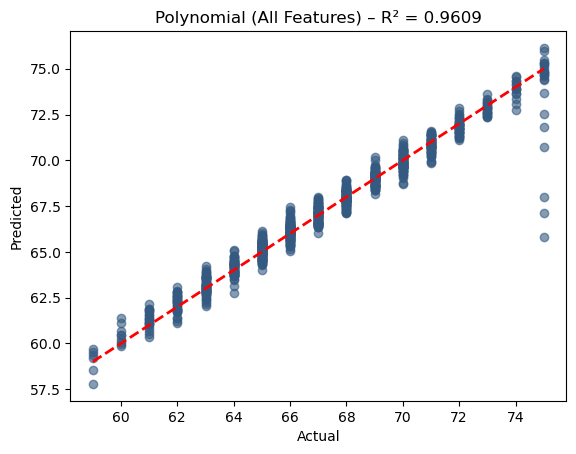

In [40]:
plt.scatter(y_valid, y_pred_poly, alpha=0.6, color='#355a81')
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Polynomial (All Features) – R² = {r2_poly:.4f}')
plt.show()

## Kiểm tra tính độc lập

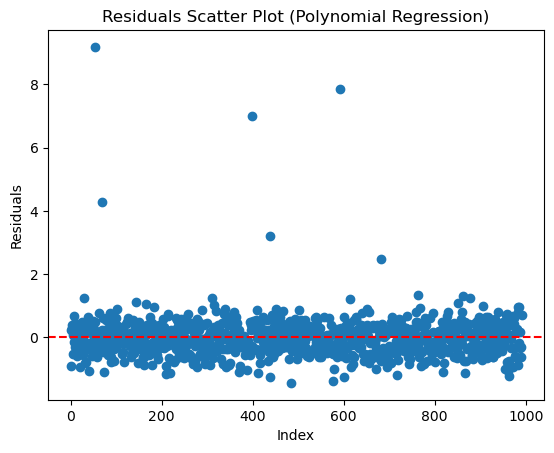

In [41]:
# Sử dụng biểu đồ Scatter Plot quan sát
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson

# Tính phần dư
residuals_poly = y_valid - y_pred_poly

# 1. Scatter plot residual theo index
plt.scatter(range(len(residuals_poly)), residuals_poly)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Index')
plt.ylabel('Residuals')
plt.title('Residuals Scatter Plot (Polynomial Regression)')
plt.show()

In [42]:
# Sử dụng công thức Durbin_Watson
dw_stat = durbin_watson(residuals_poly)
print(f'Durbin-Watson statistic: {dw_stat:.3f}')

if dw_stat < 1.5:
    print("Có positive autocorrelation (residual không độc lập).")
elif dw_stat > 2.5:
    print("Có negative autocorrelation (residual không độc lập).")
else:
    print("Residuals gần như độc lập.")

Durbin-Watson statistic: 2.031
Residuals gần như độc lập.


## Kiểm tra tính phương sai không đổi

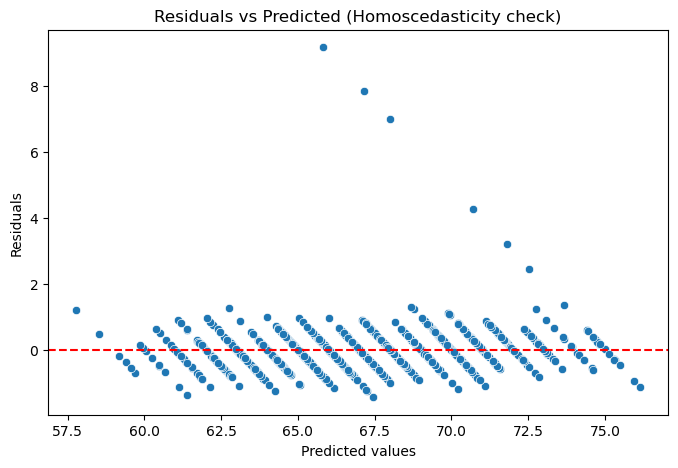

In [43]:
# Sử dụng biểu đồ dự đoán residuals_poly
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ residuals vs predicted
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred_poly, y=residuals_poly)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Homoscedasticity check)")
plt.show()


In [44]:
# Breusch-Pagan
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Thêm hằng số vào X (required cho statsmodels)
X_valid_poly_sm = sm.add_constant(X_valid_poly)

# Tạo model OLS với y và X đã chuẩn bị
model = sm.OLS(y_valid, X_valid_poly_sm).fit()

# Chạy Breusch-Pagan test
bp_test = het_breuschpagan(model.resid, model.model.exog)

labels = ['Lagrange multiplier statistic', 'p-value', 
          'f-value', 'f p-value']

# In kết quả
for label, value in zip(labels, bp_test):
    print(f"{label}: {value:.4f}")


Lagrange multiplier statistic: 385.6546
p-value: 0.0105
f-value: 1.4373
f p-value: 0.0001


## Kiểm tra phân phối chuẩn của phần dư

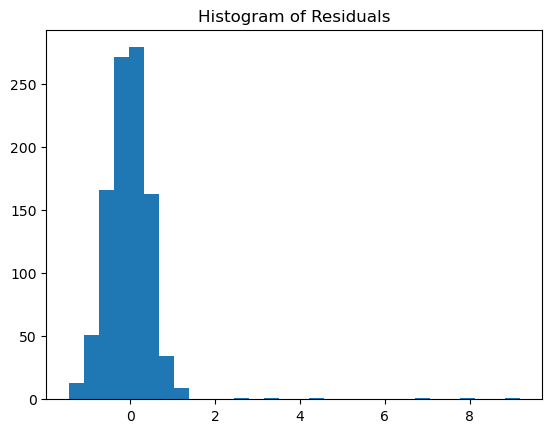

In [45]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Histogram
plt.hist(residuals_poly, bins=30)
plt.title("Histogram of Residuals")
plt.show()

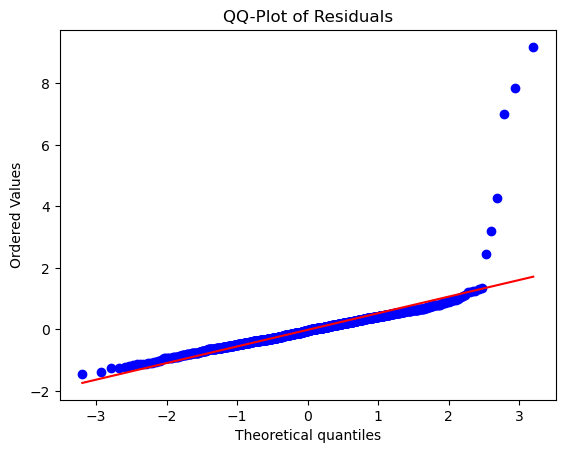

In [46]:
# QQ-plot
stats.probplot(residuals_poly, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals")
plt.show()

In [47]:
# Shapiro-Wilk test
from scipy.stats import shapiro

stat, p = shapiro(residuals_poly)
print(f"Shapiro-Wilk test: stat={stat:.4f}, p={p:.4f}")
if p > 0.05:
    print("Residuals likely normal")
else:
    print("Residuals not normal")


Shapiro-Wilk test: stat=0.6699, p=0.0000
Residuals not normal


## 6.2. KIỂM ĐỊNH LINEAR

## Test linear

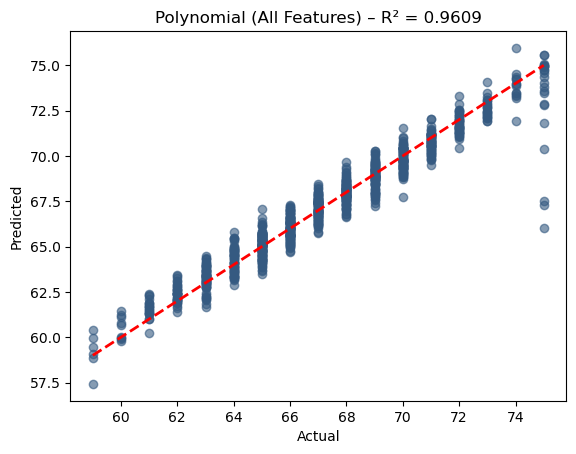

In [48]:
plt.scatter(y_valid, y_pred_linear, alpha=0.6, color='#355a81')
plt.plot([y_valid.min(), y_valid.max()], [y_valid.min(), y_valid.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Polynomial (All Features) – R² = {r2_poly:.4f}')
plt.show()

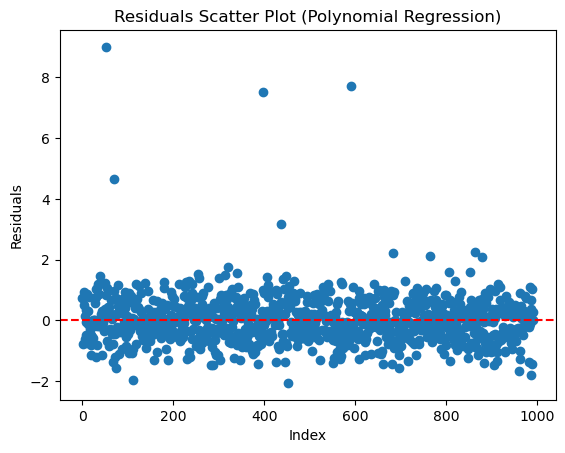

In [49]:
# Sử dụng biểu đồ Scatter Plot quan sát
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson

# Tính phần dư
residuals_linear = y_valid - y_pred_linear

# 1. Scatter plot residual theo index
plt.scatter(range(len(residuals_linear)), residuals_linear)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Index')
plt.ylabel('Residuals')
plt.title('Residuals Scatter Plot (Polynomial Regression)')
plt.show()

In [50]:
# Sử dụng công thức Durbin_Watson
dw_stat = durbin_watson(residuals_linear)
print(f'Durbin-Watson statistic: {dw_stat:.3f}')

if dw_stat < 1.5:
    print("Có positive autocorrelation (residual không độc lập).")
elif dw_stat > 2.5:
    print("Có negative autocorrelation (residual không độc lập).")
else:
    print("Residuals gần như độc lập.")

Durbin-Watson statistic: 1.980
Residuals gần như độc lập.


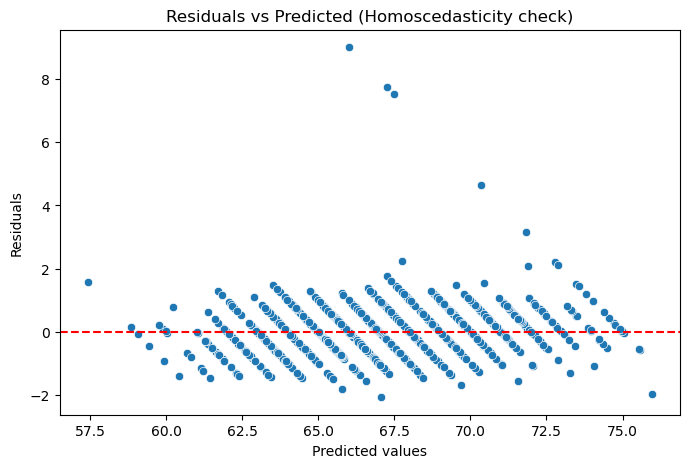

In [51]:
# Sử dụng biểu đồ dự đoán residuals_linear
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ residuals vs predicted
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred_linear, y=residuals_linear)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Homoscedasticity check)")
plt.show()

In [52]:
# Breusch-Pagan
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Thêm hằng số vào X (required cho statsmodels)
X_valid_linear_sm = sm.add_constant(X_valid)

# Tạo model OLS với y và X đã chuẩn bị
model = sm.OLS(y_valid, X_valid_linear_sm).fit()

# Chạy Breusch-Pagan test
bp_test = het_breuschpagan(model.resid, model.model.exog)

labels = ['Lagrange multiplier statistic', 'p-value', 
          'f-value', 'f p-value']

# In kết quả
for label, value in zip(labels, bp_test):
    print(f"{label}: {value:.4f}")


Lagrange multiplier statistic: 36.0602
p-value: 0.0542
f-value: 1.5199
f p-value: 0.0523


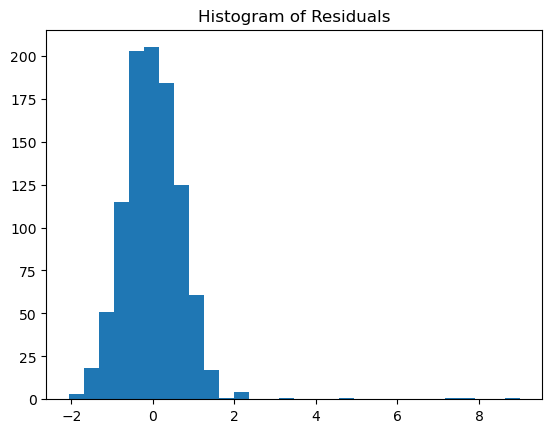

In [53]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Histogram
plt.hist(residuals_linear, bins=30)
plt.title("Histogram of Residuals")
plt.show()

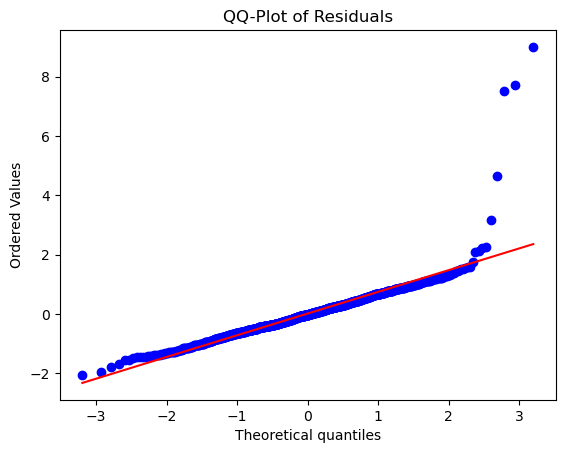

In [54]:
# QQ-plot
stats.probplot(residuals_linear, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals")
plt.show()

In [55]:
# Shapiro-Wilk test
from scipy.stats import shapiro

stat, p = shapiro(residuals_linear)
print(f"Shapiro-Wilk test: stat={stat:.4f}, p={p:.4f}")
if p > 0.05:
    print("Residuals likely normal")
else:
    print("Residuals not normal")


Shapiro-Wilk test: stat=0.8191, p=0.0000
Residuals not normal


# 7. KẾT QUẢ THỰC NGHIỆM TRÊN TẬP TEST

## 7.1. Kết quả trên mô hình Linear Regression

In [56]:
y_pred_linear_test = lr.predict(X_test)  # Predict on test set
# Đánh giá mô hình
mae = mean_absolute_error(y_test, y_pred_linear_test)
mse = mean_squared_error(y_test, y_pred_linear_test)          # Mean Squared Error
rmse = np.sqrt(mse)                                # Root Mean Squared Error
mae = mean_absolute_error(y_test, y_pred_linear_test)         # Mean Absolute Error
r2 = r2_score(y_test, y_pred_linear_test)                     # R-squared

print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}") 
print(f"Mô hình giải thích được {r2*100:.2f}% phương sai của biến mục tiêu Exam_Score") 

MAE:  0.6063
MSE:  1.3622
RMSE: 1.1672
R²:   0.8781
Mô hình giải thích được 87.81% phương sai của biến mục tiêu Exam_Score


## 7.2. Kết quả trên mô hình Polynominal Regression

In [57]:
# Transform test data using the SAME poly transformer fitted on train
X_test_poly = poly.transform(X_test)

# Predict on test set
y_pred_poly_test = poly_reg.predict(X_test_poly)

# Metrics on test set
mse_poly_test = mean_squared_error(y_test, y_pred_poly_test)
rmse_poly_test = np.sqrt(mse_poly_test)
mae_poly_test = mean_absolute_error(y_test, y_pred_poly_test)
r2_poly_test = r2_score(y_test, y_pred_poly_test)

# Print results
print(f"Polynomial MAE (test): {mae_poly_test:.4f}")
print(f"Polynomial MSE (test): {mse_poly_test:.4f}")
print(f"Polynomial RMSE(test): {rmse_poly_test:.4f}")
print(f"Polynomial R² (test):  {r2_poly_test:.4f}")
print(f"Mô hình giải thích được {r2_poly_test * 100:.2f}% phương sai của biến mục tiêu Exam_Score")


Polynomial MAE (test): 0.4391
Polynomial MSE (test): 1.1890
Polynomial RMSE(test): 1.0904
Polynomial R² (test):  0.8936
Mô hình giải thích được 89.36% phương sai của biến mục tiêu Exam_Score
